Import Required Libraries

In [ ]:
# ===============================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


Load Dataset from Google Drive

In [ ]:
# ===============================================
# STEP 2: LOAD DATASET FROM GOOGLE DRIVE
# ===============================================

file_id = "1CsT32kpqY1cnz4h38OzDtBmr6-avTTiH"  # Your dataset file ID
download_url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(download_url, encoding='latin-1')
print("✅ Dataset loaded successfully!")
print(df.head())
print("\nAvailable columns:", df.columns)


✅ Dataset loaded successfully!
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Available columns: Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


Data Cleaning and Preparation

In [ ]:
# ===============================================
# STEP 3: DATA CLEANING AND PREPARATION
# ===============================================

# Keep only the necessary columns
if 'v1' in df.columns and 'v2' in df.columns:
    df = df[['v1', 'v2']]
    df.columns = ['label', 'message']
else:
    df.columns = ['label', 'message']

# Encode labels: ham = 0, spam = 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print("\n✅ Cleaned Data Sample:")
print(df.head())
print("\n🔢 Unique Labels:", df['label'].value_counts())



✅ Cleaned Data Sample:
  label                                            message  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0

🔢 Unique Labels: label
ham     4825
spam     747
Name: count, dtype: int64


Exploratory Data Analysis (EDA)

📌 Let’s visualize the data to understand the spam vs. ham distribution and message length patterns.

/tmp/ipython-input-1765513322.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


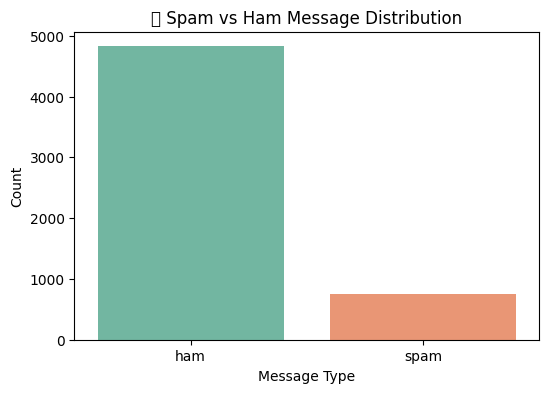

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


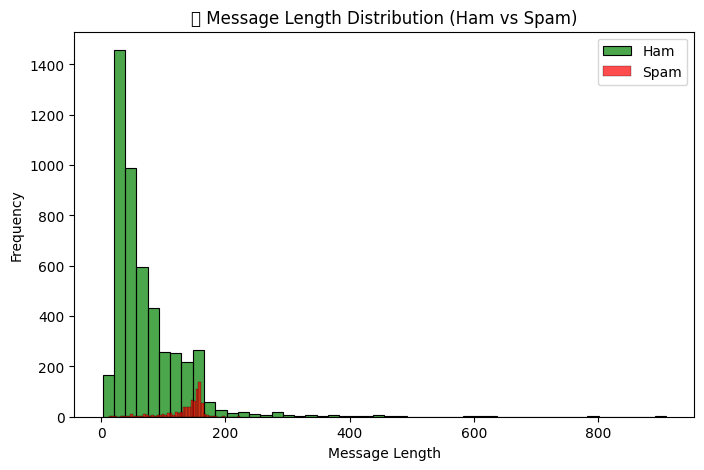

In [ ]:
# ===============================================
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# ===============================================

# 1️⃣ Count of Spam vs Ham
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title("📊 Spam vs Ham Message Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

# 2️⃣ Add message length column
df['message_length'] = df['message'].apply(len)

# 3️⃣ Visualize message length distribution
plt.figure(figsize=(8,5))
sns.histplot(df[df['label']=='ham']['message_length'], bins=50, color='green', label='Ham', alpha=0.7)
sns.histplot(df[df['label']=='spam']['message_length'], bins=50, color='red', label='Spam', alpha=0.7)
plt.legend()
plt.title("📈 Message Length Distribution (Ham vs Spam)")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()


Feature Extraction using TF-IDF

📌 We’ll convert text into numerical form using TF-IDF Vectorization so that the model can understand the data.

In [ ]:
# ===============================================
# STEP 5: TEXT VECTORIZATION (TF-IDF)
# ===============================================

vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

X = vectorizer.fit_transform(df['message'])
y = df['label_num']

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Text data vectorized and split into train/test sets!")


✅ Text data vectorized and split into train/test sets!


Model Training (Naive Bayes)

In [ ]:
# ===============================================
# STEP 6: MODEL TRAINING
# ===============================================

model = MultinomialNB()
model.fit(X_train, y_train)

print("✅ Model training complete!")


✅ Model training complete!


Model Evaluation


✅ Model Evaluation Results:
Accuracy: 96.86 %

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


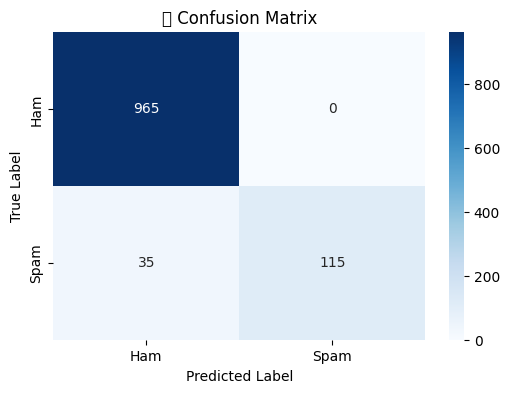

In [ ]:
# ===============================================
# STEP 7: MODEL EVALUATION
# ===============================================

y_pred = model.predict(X_test)

# Print accuracy and report
print("✅ Model Evaluation Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.title("🧩 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Test with Custom Messages

In [ ]:
# ===============================================
# STEP 8: CUSTOM MESSAGE TESTING
# ===============================================

def check_spam(message):
    msg_vec = vectorizer.transform([message])
    pred = model.predict(msg_vec)[0]
    return "🚨 Spam" if pred == 1 else "✅ Not Spam"

# Test samples
print("\n🔍 Example Predictions:")
test_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!",
    "Hey, are we meeting tomorrow for the project discussion?",
    "URGENT! Your account will be blocked. Verify your info now."
]

for msg in test_messages:
    print(f"\nMessage: {msg}\nPrediction: {check_spam(msg)}")



🔍 Example Predictions:

Message: Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!
Prediction: 🚨 Spam

Message: Hey, are we meeting tomorrow for the project discussion?
Prediction: ✅ Not Spam

Message: URGENT! Your account will be blocked. Verify your info now.
Prediction: 🚨 Spam


Save Model for Future Use

In [ ]:
# ===============================================
# STEP 9: SAVE MODEL AND VECTORIZER
# ===============================================

joblib.dump(model, "spam_detector_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("\n💾 Model and vectorizer saved successfully!")



💾 Model and vectorizer saved successfully!
